# SOB4ES - Comparativa de modelos
### CRISP-ML(Q) - Fase 4: Evaluacion comparada de los modelos

Este notebook consolida los resultados de evaluacion final (`eval.csv`) de los **8 enfoques de modelado** desarrollados en el proyecto y anade una seccion especifica para identificar, **por cada target**, cual es el **modelo menos relevante** (el de peor rendimiento).

**Modelos comparados:**
1. `rf-model.ipynb` &rarr; Random Forest (un modelo independiente por target)
2. `rf_multisalida.ipynb` &rarr; Random Forest multisalida (un unico modelo para los 21 targets)
3. `xgboost-model.ipynb` &rarr; XGBoost (un modelo independiente por target)
4. `xgb_multisalida.ipynb` &rarr; XGBoost multisalida (`multi_strategy='multi_output_tree'`)
5. `reg-model.ipynb` &rarr; Regresion Ridge (un modelo independiente por target, con su propio `alpha`)
6. `regressorchain.ipynb` &rarr; RegressorChain (ensemble de 10 cadenas con RF como modelo base)
7. `mlp_multisalida.ipynb` &rarr; Red neuronal (MLP) multisalida, perdida MSE estandar
8. `mlp_custom_loss.ipynb` &rarr; Red neuronal (MLP) multisalida con perdida que penaliza rupturas de correlacion entre targets

**Metrica de comparacion:** R2 sobre `eval.csv` (conjunto de evaluacion final, no usado en ningun momento del tuning ni del entrenamiento), tal y como se reporta en la seccion 7 de cada notebook.

---
## 1.- Configuracion y carga de resultados

Para que este notebook funcione de forma autonoma (sin necesidad de volver a entrenar los 8 modelos), se intenta primero **recalcular las metricas reales** cargando los modelos `.pkl` / `.pt` guardados por cada notebook y evaluandolos sobre `eval.csv`. Si esos artefactos no estan disponibles en el entorno actual, se recurre a la tabla de resultados **capturada de la ultima ejecucion registrada** de cada notebook (la que aparece en la seccion 7 de cada uno), dejando constancia explicita de que fuente se ha usado.


In [13]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]

# Paleta de colores unificada (misma que el resto de notebooks del proyecto)
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
    'red':          '#D98686',
}
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

print('Librerias y variables cargadas correctamente...')


Librerias y variables cargadas correctamente...


In [14]:
# Resultados de referencia: R2 sobre eval.csv, capturados de la seccion 7
# ("Evaluacion final") de la ultima ejecucion registrada de cada notebook.
# Si se dispone de los modelos entrenados (.pkl / .pt) y de eval.csv en este
# entorno, la siguiente celda los recalcula en vivo y sustituye estos valores.

R2_REFERENCIA = {
    'Random Forest': {
        'nematode_shannon_z': 0.1141, 'macro_shannon_z': 0.2797, 'earthworm_shannon_z': 0.5039,
        'orib_shannon_z': 0.1773, 'meso_shannon_z': -0.1710, 'coll_shannon_z': -0.4899,
        'bac_shannon_z': -0.0071, 'fun_shannon_z': -0.0465, 'euk_shannon_z': 0.1513,
        'oomy_shannon_z': 0.0943, 'cerc_shannon_z': -0.0275, 'macro_order_richness_z': 0.3160,
        'earthworm_richness_z': 0.5449, 'orib_species_richness_z': 0.2063, 'meso_species_richness_z': -0.0351,
        'coll_species_richness_z': -0.7116, 'bac_asv_richness_z': 0.0048, 'fun_asv_richness_z': -0.0282,
        'euk_asv_richness_z': 0.2501, 'oomy_asv_richness_z': 0.1930, 'cerc_asv_richness_z': 0.1278,
    },
    'RF Multisalida': {
        'nematode_shannon_z': 0.2009, 'macro_shannon_z': 0.2545, 'earthworm_shannon_z': 0.5003,
        'orib_shannon_z': 0.2030, 'meso_shannon_z': -0.1493, 'coll_shannon_z': -0.2276,
        'bac_shannon_z': 0.0482, 'fun_shannon_z': -0.0293, 'euk_shannon_z': 0.1648,
        'oomy_shannon_z': 0.1318, 'cerc_shannon_z': 0.0134, 'macro_order_richness_z': 0.3150,
        'earthworm_richness_z': 0.5289, 'orib_species_richness_z': 0.2723, 'meso_species_richness_z': -0.0478,
        'coll_species_richness_z': -0.3923, 'bac_asv_richness_z': 0.0059, 'fun_asv_richness_z': -0.0109,
        'euk_asv_richness_z': 0.2249, 'oomy_asv_richness_z': 0.2622, 'cerc_asv_richness_z': 0.1313,
    },
    'XGBoost': {
        'nematode_shannon_z': 0.1644, 'macro_shannon_z': 0.3990, 'earthworm_shannon_z': 0.5383,
        'orib_shannon_z': 0.2448, 'meso_shannon_z': -0.2950, 'coll_shannon_z': -0.4482,
        'bac_shannon_z': -0.0439, 'fun_shannon_z': -0.0477, 'euk_shannon_z': 0.0396,
        'oomy_shannon_z': 0.0220, 'cerc_shannon_z': -0.0652, 'macro_order_richness_z': 0.4683,
        'earthworm_richness_z': 0.6091, 'orib_species_richness_z': 0.3113, 'meso_species_richness_z': -0.1421,
        'coll_species_richness_z': -0.7689, 'bac_asv_richness_z': 0.0407, 'fun_asv_richness_z': -0.0864,
        'euk_asv_richness_z': 0.2048, 'oomy_asv_richness_z': 0.1505, 'cerc_asv_richness_z': 0.0408,
    },
    'XGB Multisalida': {
        'nematode_shannon_z': 0.1793, 'macro_shannon_z': 0.4068, 'earthworm_shannon_z': 0.5409,
        'orib_shannon_z': 0.2501, 'meso_shannon_z': -0.3313, 'coll_shannon_z': -0.4238,
        'bac_shannon_z': -0.0399, 'fun_shannon_z': -0.0602, 'euk_shannon_z': 0.0585,
        'oomy_shannon_z': 0.0368, 'cerc_shannon_z': -0.0740, 'macro_order_richness_z': 0.4701,
        'earthworm_richness_z': 0.6066, 'orib_species_richness_z': 0.2819, 'meso_species_richness_z': -0.1185,
        'coll_species_richness_z': -0.7461, 'bac_asv_richness_z': 0.0323, 'fun_asv_richness_z': -0.0996,
        'euk_asv_richness_z': 0.2123, 'oomy_asv_richness_z': 0.1428, 'cerc_asv_richness_z': 0.0560,
    },
    'Ridge': {
        'nematode_shannon_z': 0.0112, 'macro_shannon_z': 0.1257, 'earthworm_shannon_z': 0.2395,
        'orib_shannon_z': 0.1137, 'meso_shannon_z': -0.2499, 'coll_shannon_z': -0.4998,
        'bac_shannon_z': -0.0812, 'fun_shannon_z': -0.0161, 'euk_shannon_z': 0.0407,
        'oomy_shannon_z': 0.0857, 'cerc_shannon_z': 0.0155, 'macro_order_richness_z': 0.1521,
        'earthworm_richness_z': 0.2789, 'orib_species_richness_z': 0.0921, 'meso_species_richness_z': -0.0959,
        'coll_species_richness_z': -0.7341, 'bac_asv_richness_z': -0.0761, 'fun_asv_richness_z': 0.0087,
        'euk_asv_richness_z': 0.0400, 'oomy_asv_richness_z': 0.1035, 'cerc_asv_richness_z': 0.1019,
    },
    'RegressorChain': {
        'nematode_shannon_z': 0.1659, 'macro_shannon_z': 0.3408, 'earthworm_shannon_z': 0.5450,
        'orib_shannon_z': 0.2478, 'meso_shannon_z': -0.2449, 'coll_shannon_z': -0.6500,
        'bac_shannon_z': -0.0096, 'fun_shannon_z': -0.0265, 'euk_shannon_z': 0.2065,
        'oomy_shannon_z': 0.0867, 'cerc_shannon_z': 0.0266, 'macro_order_richness_z': 0.4561,
        'earthworm_richness_z': 0.5895, 'orib_species_richness_z': 0.2362, 'meso_species_richness_z': -0.0650,
        'coll_species_richness_z': -0.5584, 'bac_asv_richness_z': -0.0673, 'fun_asv_richness_z': -0.0277,
        'euk_asv_richness_z': 0.3184, 'oomy_asv_richness_z': 0.2145, 'cerc_asv_richness_z': 0.1076,
    },
    'MLP Multisalida': {
        'nematode_shannon_z': 0.1461, 'macro_shannon_z': 0.2717, 'earthworm_shannon_z': 0.4372,
        'orib_shannon_z': 0.2763, 'meso_shannon_z': -0.2232, 'coll_shannon_z': -0.2475,
        'bac_shannon_z': -0.0584, 'fun_shannon_z': -0.0353, 'euk_shannon_z': 0.1850,
        'oomy_shannon_z': 0.1427, 'cerc_shannon_z': -0.1139, 'macro_order_richness_z': 0.3658,
        'earthworm_richness_z': 0.5285, 'orib_species_richness_z': 0.3325, 'meso_species_richness_z': -0.0717,
        'coll_species_richness_z': -0.4733, 'bac_asv_richness_z': -0.0987, 'fun_asv_richness_z': 0.0123,
        'euk_asv_richness_z': 0.2822, 'oomy_asv_richness_z': 0.0581, 'cerc_asv_richness_z': 0.0623,
    },
    'MLP Perdida Personalizada': {
        'nematode_shannon_z': 0.1000, 'macro_shannon_z': 0.2584, 'earthworm_shannon_z': 0.4281,
        'orib_shannon_z': 0.2341, 'meso_shannon_z': -0.3479, 'coll_shannon_z': -0.2004,
        'bac_shannon_z': -0.0481, 'fun_shannon_z': -0.0714, 'euk_shannon_z': 0.1445,
        'oomy_shannon_z': 0.0447, 'cerc_shannon_z': -0.1124, 'macro_order_richness_z': 0.3671,
        'earthworm_richness_z': 0.5215, 'orib_species_richness_z': 0.3006, 'meso_species_richness_z': -0.1928,
        'coll_species_richness_z': -0.3747, 'bac_asv_richness_z': -0.0915, 'fun_asv_richness_z': 0.0019,
        'euk_asv_richness_z': 0.2052, 'oomy_asv_richness_z': 0.0883, 'cerc_asv_richness_z': 0.0543,
    },
}

MODELOS = list(R2_REFERENCIA.keys())
print(f'Modelos de referencia cargados: {len(MODELOS)}')
for m in MODELOS:
    print(f'  - {m}')


Modelos de referencia cargados: 8
  - Random Forest
  - RF Multisalida
  - XGBoost
  - XGB Multisalida
  - Ridge
  - RegressorChain
  - MLP Multisalida
  - MLP Perdida Personalizada


## 2.- Recalculo en vivo (opcional)

Si en este entorno existen `input/eval.csv` y las carpetas `output/models/...` generadas por cada notebook, la siguiente celda recalcula el R2 real de cada modelo sobre `eval.csv` y sustituye la tabla de referencia. Si no estan disponibles, se usa la tabla de referencia de la celda anterior tal cual, y se muestra un aviso.

Ademas, si tambien existe `input/train.csv`, se construye para **Ridge** un pseudo-ensamble por bootstrap (reentrenos sobre remuestreos de `train.csv`, con los mismos hiperparametros que el modelo de produccion) para que la Seccion 6.3 pueda calcular tambien su IC empirico, igual que para el resto de modelos. Ridge es el unico modelo del proyecto sin un ensamble real de produccion, por eso necesita este paso adicional.


In [15]:
from sklearn.metrics import r2_score

DATA_DIR = './input/'
RUTAS_MODELOS = {
    'Random Forest':             './output/models/rf/',
    'RF Multisalida':            './output/models/rf_multi/',
    'XGBoost':                   './output/models/xgb/',
    'XGB Multisalida':           './output/models/xgb_multi/',
    'Ridge':                     './output/models/reg/',
    'RegressorChain':            './output/models/chain/',
    'MLP Multisalida':           './output/models/mlp/',
    'MLP Perdida Personalizada': './output/models/mlp_custom/',
}

FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    #'cu_z',
    'k_z',
    #'mo_z',
    #'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

eval_csv_path = os.path.join(DATA_DIR, 'eval.csv')
R2_POR_TARGET_MODELO = {m: dict(vals) for m, vals in R2_REFERENCIA.items()}
FUENTE = 'tabla de referencia (ultima ejecucion registrada de cada notebook)'

# PREDICCIONES_MIEMBROS[modelo][target] -> array (n_miembros, n_obs).
# Solo se rellena si hay recalculo en vivo (lo usa la seccion 6, IC empirico).
PREDICCIONES_MIEMBROS = {}

if os.path.exists(eval_csv_path) and all(os.path.isdir(p) for p in RUTAS_MODELOS.values()):
    try:
        df_eval = pd.read_csv(eval_csv_path)
        if len(df_eval.columns) < 5:
            df_eval = pd.read_csv(eval_csv_path, sep=';')
        X_eval = df_eval[FEATURES_AUTORIZADAS]
        y_eval = df_eval[TARGETS]

        recalculado = {m: {} for m in MODELOS}

        # Random Forest / XGBoost: ensamble de 5 modelos por target
        for nombre, prefijo, carpeta in [('Random Forest', 'rf_prod', RUTAS_MODELOS['Random Forest']),
                                          ('XGBoost', 'xgb_prod', RUTAS_MODELOS['XGBoost'])]:
            sufijo = 'm' if nombre == 'Random Forest' else 'exp'
            PREDICCIONES_MIEMBROS[nombre] = {}
            for t in TARGETS:
                preds = [joblib.load(os.path.join(carpeta, f'{prefijo}_{t}_{sufijo}{i}.pkl')).predict(X_eval)
                         for i in range(5)]
                PREDICCIONES_MIEMBROS[nombre][t] = np.array(preds)
                y_pred = np.mean(preds, axis=0)
                recalculado[nombre][t] = r2_score(y_eval[t].values, y_pred)

        # Ridge: un unico modelo por target (sin ensamble propio).
        # Si ademas existe train.csv, se construye un pseudo-ensamble por
        # bootstrap (N_BOOTSTRAP_RIDGE reentrenos sobre remuestreos de
        # X_train/y_train, con los mismos hiperparametros del modelo de
        # produccion) para poder calcular tambien su IC empirico en la
        # seccion 6.3, igual que el resto de modelos.
        from sklearn.linear_model import Ridge
        from sklearn.utils import resample

        N_BOOTSTRAP_RIDGE = 5
        train_csv_path = os.path.join(DATA_DIR, 'train.csv')
        hay_train_data = os.path.exists(train_csv_path)

        if hay_train_data:
            df_train = pd.read_csv(train_csv_path)
            if len(df_train.columns) < 5:
                df_train = pd.read_csv(train_csv_path, sep=';')
            X_train = df_train[FEATURES_AUTORIZADAS]
            y_train = df_train[TARGETS]
            PREDICCIONES_MIEMBROS['Ridge'] = {}

        for t in TARGETS:
            m = joblib.load(os.path.join(RUTAS_MODELOS['Ridge'], f'ridge_prod_{t}.pkl'))
            recalculado['Ridge'][t] = r2_score(y_eval[t].values, m.predict(X_eval))

            if hay_train_data:
                params_ridge = m.get_params()  # mismos hiperparametros que el modelo de produccion
                y_t = y_train[t].values
                preds_boot = []
                for b in range(N_BOOTSTRAP_RIDGE):
                    X_boot, y_boot = resample(X_train, y_t, replace=True, random_state=b)
                    modelo_boot = Ridge(**params_ridge)
                    modelo_boot.fit(X_boot, y_boot)
                    preds_boot.append(modelo_boot.predict(X_eval))
                PREDICCIONES_MIEMBROS['Ridge'][t] = np.array(preds_boot)

        # RF / XGB multisalida: ensamble de 5 modelos multisalida
        for nombre, prefijo, carpeta in [('RF Multisalida', 'rf_multi_m', RUTAS_MODELOS['RF Multisalida']),
                                          ('XGB Multisalida', 'xgb_multi_exp', RUTAS_MODELOS['XGB Multisalida'])]:
            preds = [joblib.load(os.path.join(carpeta, f'{prefijo}{i}.pkl')).predict(X_eval) for i in range(5)]
            preds_arr = np.array(preds)  # (miembros, obs, targets)
            PREDICCIONES_MIEMBROS[nombre] = {t: preds_arr[:, :, j] for j, t in enumerate(TARGETS)}
            y_pred = preds_arr.mean(axis=0)
            r2_raw = r2_score(y_eval.values, y_pred, multioutput='raw_values')
            recalculado[nombre] = dict(zip(TARGETS, r2_raw))

        # RegressorChain: ensamble de N cadenas
        chain_dir = RUTAS_MODELOS['RegressorChain']
        chain_files = sorted(f for f in os.listdir(chain_dir) if f.startswith('chain_') and f.endswith('.pkl'))
        preds = [joblib.load(os.path.join(chain_dir, f)).predict(X_eval) for f in chain_files]
        preds_arr = np.array(preds)
        PREDICCIONES_MIEMBROS['RegressorChain'] = {t: preds_arr[:, :, j] for j, t in enumerate(TARGETS)}
        y_pred = preds_arr.mean(axis=0)
        r2_raw = r2_score(y_eval.values, y_pred, multioutput='raw_values')
        recalculado['RegressorChain'] = dict(zip(TARGETS, r2_raw))

        # MLP (requiere torch)
        import torch
        import torch.nn as nn

        class MLPMultiSalida(nn.Module):
            def __init__(self, n_inputs, n_outputs, hidden_sizes, dropout_rate):
                super().__init__()
                layers = []
                in_size = n_inputs
                for h in hidden_sizes:
                    layers += [nn.Linear(in_size, h), nn.ReLU(), nn.Dropout(dropout_rate)]
                    in_size = h
                layers.append(nn.Linear(in_size, n_outputs))
                self.red = nn.Sequential(*layers)
            def forward(self, x):
                return self.red(x)

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        for nombre, carpeta, cfg_name, pt_prefix in [
            ('MLP Multisalida', RUTAS_MODELOS['MLP Multisalida'], 'mlp_config.pkl', 'mlp_prod_'),
            ('MLP Perdida Personalizada', RUTAS_MODELOS['MLP Perdida Personalizada'], 'mlp_custom_config.pkl', 'mlp_custom_'),
        ]:
            cfg = joblib.load(os.path.join(carpeta, cfg_name))
            preds = []
            for i in range(5):
                model = MLPMultiSalida(len(FEATURES_AUTORIZADAS), len(TARGETS), cfg['hidden'], cfg['dropout']).to(device)
                model.load_state_dict(torch.load(os.path.join(carpeta, f'{pt_prefix}{i}.pt'), map_location=device))
                model.eval()
                with torch.no_grad():
                    X_t = torch.tensor(X_eval.values, dtype=torch.float32).to(device)
                    preds.append(model(X_t).cpu().numpy())
            preds_arr = np.array(preds)
            PREDICCIONES_MIEMBROS[nombre] = {t: preds_arr[:, :, j] for j, t in enumerate(TARGETS)}
            y_pred = preds_arr.mean(axis=0)
            r2_raw = r2_score(y_eval.values, y_pred, multioutput='raw_values')
            recalculado[nombre] = dict(zip(TARGETS, r2_raw))

        R2_POR_TARGET_MODELO = recalculado
        FUENTE = 'recalculo en vivo sobre eval.csv (modelos cargados desde disco)'
    except Exception as e:
        print(f'Aviso: fallo el recalculo en vivo ({e}). Se usa la tabla de referencia.')
        PREDICCIONES_MIEMBROS = {}

print(f'Fuente de las metricas utilizadas en este notebook: {FUENTE}')
if PREDICCIONES_MIEMBROS:
    modelos_con_miembros = list(PREDICCIONES_MIEMBROS.keys())
    print(f'Predicciones individuales disponibles para: {modelos_con_miembros}')
    if 'Ridge' in modelos_con_miembros:
        print('  (el ensamble de Ridge es un pseudo-ensamble por bootstrap sobre train.csv, '
              'no un ensamble real de produccion como el resto de modelos)')
    faltantes = [m for m in MODELOS if m not in modelos_con_miembros]
    if faltantes:
        print(f'Sin predicciones individuales (solo aproximacion por R2) para: {faltantes}')
else:
    print('Predicciones individuales del ensamble NO disponibles: la seccion 6 usara '
          'solo la aproximacion basada en R2.')


Fuente de las metricas utilizadas en este notebook: recalculo en vivo sobre eval.csv (modelos cargados desde disco)
Predicciones individuales disponibles para: ['Random Forest', 'XGBoost', 'Ridge', 'RF Multisalida', 'XGB Multisalida', 'RegressorChain', 'MLP Multisalida', 'MLP Perdida Personalizada']
  (el ensamble de Ridge es un pseudo-ensamble por bootstrap sobre train.csv, no un ensamble real de produccion como el resto de modelos)


## 3.- Tabla de rendimiento (R2 por modelo y target)

Matriz completa de R2 (evaluacion final sobre `eval.csv`) para los 8 modelos y los 21 targets.


In [16]:
df_r2 = pd.DataFrame(R2_POR_TARGET_MODELO)[MODELOS].loc[TARGETS]
pd.set_option('display.width', 160)
pd.set_option('display.max_rows', 30)
print(df_r2.round(4).to_string())


                         Random Forest  RF Multisalida  XGBoost  XGB Multisalida   Ridge  RegressorChain  MLP Multisalida  MLP Perdida Personalizada
nematode_shannon_z              0.1360          0.1527   0.1492           0.2189 -0.0006          0.1434           0.0656                     0.0482
macro_shannon_z                 0.2788          0.2103   0.2697           0.3894  0.1231          0.2995           0.2066                     0.1918
earthworm_shannon_z             0.4932          0.4178   0.5012           0.5482  0.2430          0.5049           0.3591                     0.3776
orib_shannon_z                  0.1884          0.1708   0.1446           0.2400  0.0989          0.2396           0.2250                     0.2009
meso_shannon_z                 -0.1995         -0.1251  -0.2002          -0.3146 -0.2932         -0.2102          -0.2448                    -0.3789
coll_shannon_z                 -0.3569         -0.1931  -0.3515          -0.4247 -0.5990         -0.7197  

### 3.1 Ranking global de modelos

La tabla anterior es útil target a target, pero conviene tener también una vista agregada: ¿qué modelo rinde mejor **en promedio**, a través de los 21 targets? Se calcula la media y la mediana del R2 por modelo (la mediana es menos sensible a los targets con R2 muy negativo, que pueden distorsionar la media).


Ranking global de modelos (promediado sobre los 21 targets)
--------------------------------------------------
                           r2_medio  r2_mediana
RF Multisalida               0.0982      0.1288
Random Forest                0.0849      0.1257
XGB Multisalida              0.0804      0.0854
RegressorChain               0.0783      0.1157
XGBoost                      0.0685      0.1011
MLP Multisalida             -0.0006      0.0662
Ridge                       -0.0258      0.0525
MLP Perdida Personalizada   -0.0428      0.0482


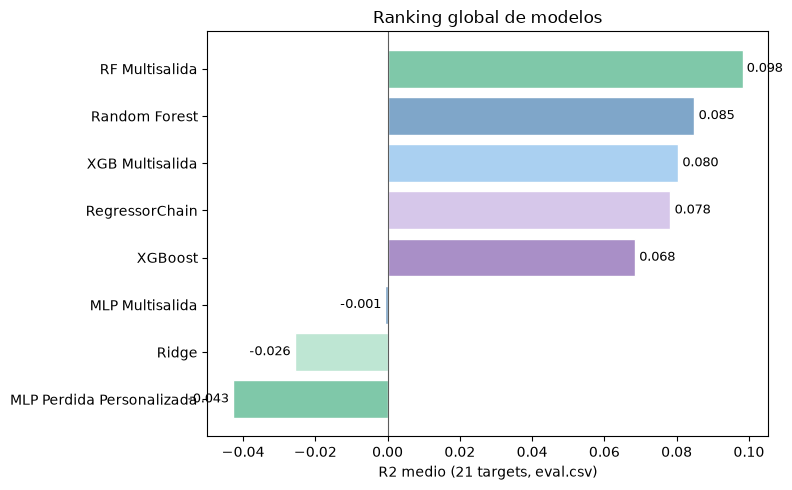

In [17]:
ranking_global = pd.DataFrame({
    'r2_medio':   df_r2.mean(axis=0),
    'r2_mediana': df_r2.median(axis=0),
}).sort_values('r2_medio', ascending=False)

# Un color fijo por modelo, reutilizado en el resto del notebook
colores_modelo = dict(zip(MODELOS, palette_cycle(len(MODELOS))))

print('Ranking global de modelos (promediado sobre los 21 targets)')
print('-' * 50)
print(ranking_global.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
orden = ranking_global.index
bars = ax.barh(orden, ranking_global.loc[orden, 'r2_medio'],
               color=[colores_modelo[m] for m in orden], edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color=PALETTE['gray_dark'], linewidth=0.8)
ax.set_xlabel('R2 medio (21 targets, eval.csv)')
ax.set_title('Ranking global de modelos', fontsize=12)
plt.tight_layout()
plt.show()


## 4.- Modelos menos relevantes por target

Para cada target se identifica el **modelo menos relevante**: aquel con el **R2 mas bajo** sobre `eval.csv` entre los 8 enfoques comparados. Un R2 negativo indica que el modelo predice peor que si simplemente se usara la media del target como prediccion constante.


In [18]:
# Modelo menos relevante (peor R2) para cada target
peor_modelo_por_target = df_r2.idxmin(axis=1)
peor_r2_por_target     = df_r2.min(axis=1)

# Mejor modelo por target, para dar contexto (cuanto se pierde eligiendo el peor)
mejor_modelo_por_target = df_r2.idxmax(axis=1)
mejor_r2_por_target     = df_r2.max(axis=1)

resumen_menos_relevantes = pd.DataFrame({
    'modelo_menos_relevante': peor_modelo_por_target,
    'r2_menos_relevante':     peor_r2_por_target.round(4),
    'modelo_mas_relevante':   mejor_modelo_por_target,
    'r2_mas_relevante':       mejor_r2_por_target.round(4),
    'brecha_r2':              (mejor_r2_por_target - peor_r2_por_target).round(4),
})

print('=' * 78)
print('MODELO MENOS RELEVANTE POR TARGET (peor R2 en eval.csv)')
print('=' * 78)
for target in TARGETS:
    fila = resumen_menos_relevantes.loc[target]
    print(f'{target:28} -> {fila["modelo_menos_relevante"]:26} '
          f'(R2 = {fila["r2_menos_relevante"]:+.4f})  '
          f'| mejor: {fila["modelo_mas_relevante"]:26} (R2 = {fila["r2_mas_relevante"]:+.4f})')

print('\n' + '=' * 78)
print('FRECUENCIA: NUMERO DE TARGETS EN LOS QUE CADA MODELO ES EL MENOS RELEVANTE')
print('=' * 78)
conteo_menos_relevante = peor_modelo_por_target.value_counts()
for modelo in MODELOS:
    n = conteo_menos_relevante.get(modelo, 0)
    print(f'  {modelo:26} {n:2d} / {len(TARGETS)} targets')


MODELO MENOS RELEVANTE POR TARGET (peor R2 en eval.csv)
nematode_shannon_z           -> Ridge                      (R2 = -0.0006)  | mejor: XGB Multisalida            (R2 = +0.2189)
macro_shannon_z              -> Ridge                      (R2 = +0.1231)  | mejor: XGB Multisalida            (R2 = +0.3894)
earthworm_shannon_z          -> Ridge                      (R2 = +0.2430)  | mejor: XGB Multisalida            (R2 = +0.5482)
orib_shannon_z               -> Ridge                      (R2 = +0.0989)  | mejor: XGB Multisalida            (R2 = +0.2400)
meso_shannon_z               -> MLP Perdida Personalizada  (R2 = -0.3789)  | mejor: RF Multisalida             (R2 = -0.1251)
coll_shannon_z               -> MLP Perdida Personalizada  (R2 = -0.9949)  | mejor: RF Multisalida             (R2 = -0.1931)
bac_shannon_z                -> Ridge                      (R2 = -0.0677)  | mejor: RF Multisalida             (R2 = +0.0306)
fun_shannon_z                -> MLP Multisalida            (R2

## 5.- Visualizacion

### 5.1 Mapa de calor: R2 por modelo y target

Vision de conjunto del rendimiento de los 8 modelos sobre los 21 targets. Las celdas mas oscuras/moradas representan mejor R2; las celdas claras o en la parte inferior de la escala representan R2 bajo o negativo (peor rendimiento).


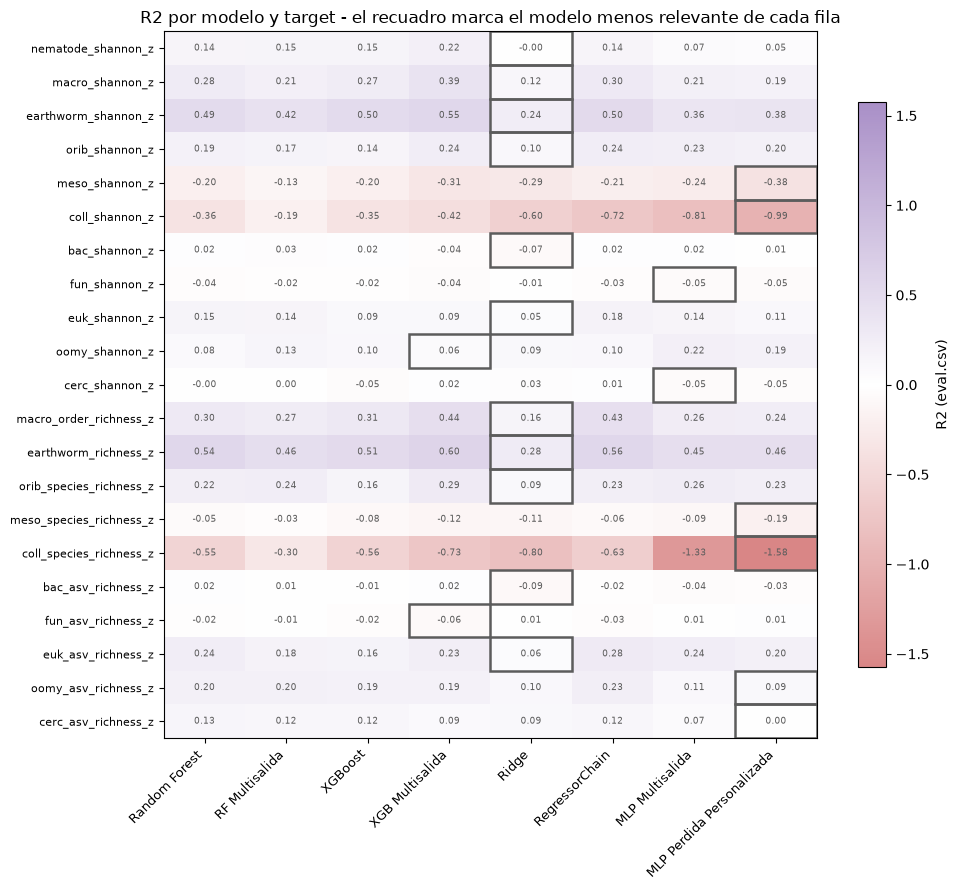

In [19]:
PALETTE_CMAP_DIV = LinearSegmentedColormap.from_list(
    'sob4es_diverging', [PALETTE['red'], '#FFFFFF', PALETTE['purple']]
)

fig, ax = plt.subplots(figsize=(10, 9))
data = df_r2.values
vmax = np.nanmax(np.abs(data))
im = ax.imshow(data, cmap=PALETTE_CMAP_DIV, vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(len(MODELOS)))
ax.set_xticklabels(MODELOS, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(TARGETS)))
ax.set_yticklabels(TARGETS, fontsize=8)

for i in range(len(TARGETS)):
    for j in range(len(MODELOS)):
        ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center', fontsize=6.5,
                color=PALETTE['gray_dark'])

# Resaltamos el modelo menos relevante de cada fila con un recuadro
for i, target in enumerate(TARGETS):
    j = MODELOS.index(peor_modelo_por_target[target])
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                edgecolor=PALETTE['gray_dark'], linewidth=1.8))

fig.colorbar(im, ax=ax, label='R2 (eval.csv)', shrink=0.8)
ax.set_title('R2 por modelo y target - el recuadro marca el modelo menos relevante de cada fila', fontsize=12)
plt.tight_layout()
plt.show()


### 5.2 R2 del modelo menos relevante por target

Cada barra muestra el R2 del peor modelo para ese target. Las barras mas cortas (o negativas) senalan los targets donde ningun modelo logra un ajuste aceptable; el color/etiqueta indica que modelo concreto es el menos relevante en cada caso.


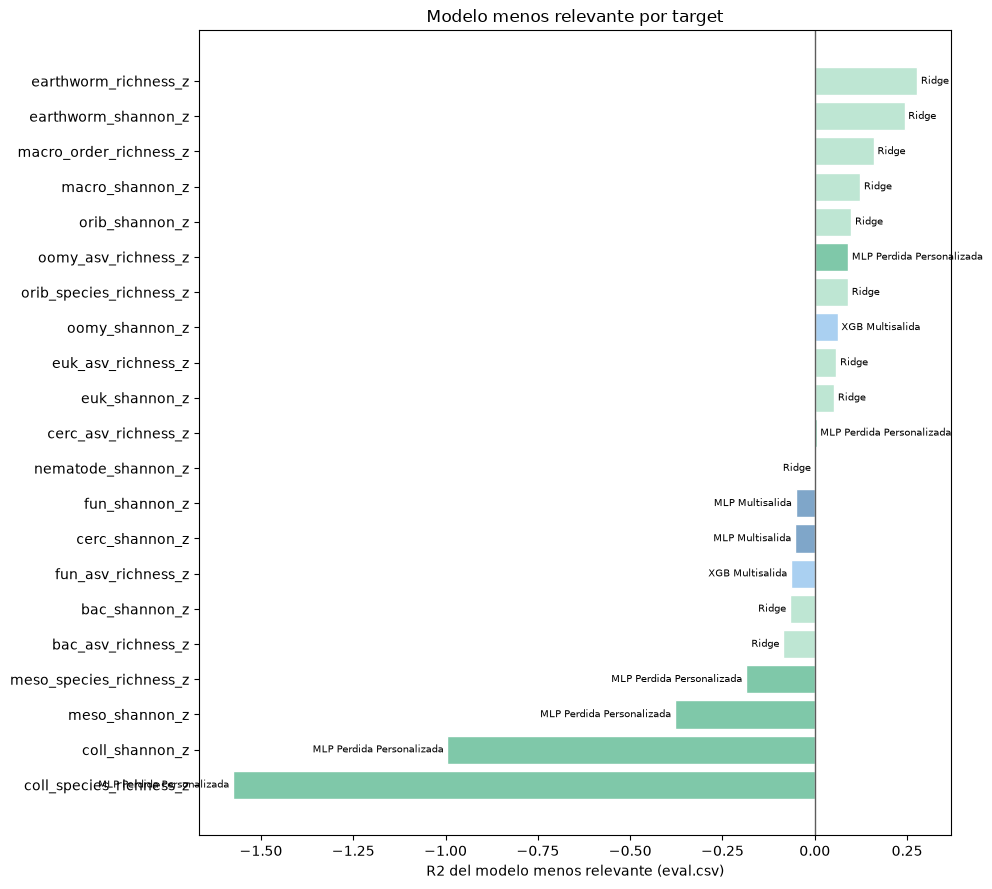

In [20]:
orden = peor_r2_por_target.sort_values().index

fig, ax = plt.subplots(figsize=(10, 9))
valores = peor_r2_por_target.loc[orden]
etiquetas_modelo = peor_modelo_por_target.loc[orden]
colores_barras = [colores_modelo[m] for m in etiquetas_modelo]

bars = ax.barh(orden, valores.values, color=colores_barras, edgecolor='white')
for bar, modelo in zip(bars, etiquetas_modelo):
    ax.text(bar.get_width() + (0.01 if bar.get_width() >= 0 else -0.01),
            bar.get_y() + bar.get_height() / 2, modelo,
            va='center', ha='left' if bar.get_width() >= 0 else 'right', fontsize=7.5)

ax.axvline(0, color=PALETTE['gray_dark'], linewidth=1)
ax.set_xlabel('R2 del modelo menos relevante (eval.csv)')
ax.set_title('Modelo menos relevante por target', fontsize=12)
plt.tight_layout()
plt.show()


### 5.3 Cuantas veces es cada modelo "el menos relevante"

Recuento, a lo largo de los 21 targets, de cuantas veces cada modelo resulta ser el de peor R2. Un valor alto sugiere que ese enfoque, en su configuracion actual, generaliza peor que las alternativas para una parte importante de las variables objetivo.


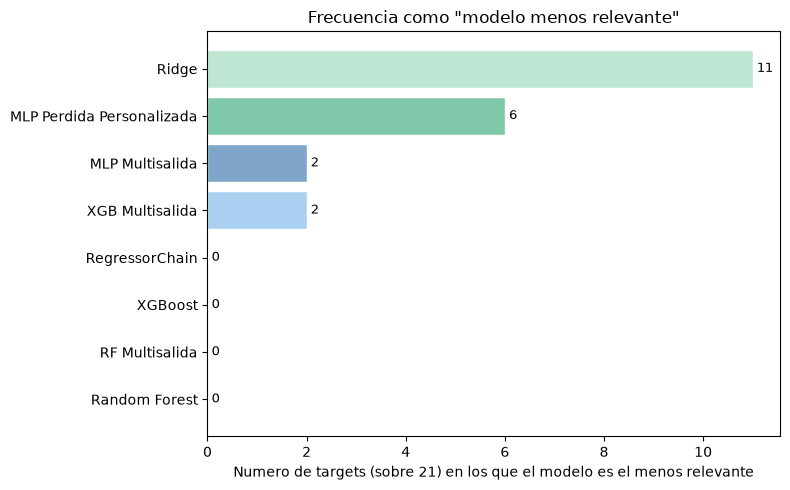

In [21]:
conteo = peor_modelo_por_target.value_counts().reindex(MODELOS, fill_value=0).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(conteo.index, conteo.values,
               color=[colores_modelo[m] for m in conteo.index], edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_xlabel(f'Numero de targets (sobre {len(TARGETS)}) en los que el modelo es el menos relevante')
ax.set_title('Frecuencia como "modelo menos relevante"', fontsize=12)
plt.tight_layout()
plt.show()


## 6.- Calculo de confianza de las predicciones

El R2 sobre `eval.csv` resume el rendimiento *promedio* de un modelo, pero no dice nada sobre que tan seguro se puede estar de **una prediccion individual concreta**. Esta seccion añade una medida de confianza por target y modelo, documentada en detalle en `documentacion_confianza_predicciones.md` (mismo directorio). En resumen se calculan dos niveles, de menor a mayor precision:

1. **Aproximacion global a partir del R2** (siempre disponible, incluso con la tabla de referencia): como los targets estan tipificados (z-score, varianza ~= 1), el error residual se puede aproximar como `RMSE_aprox = sqrt(max(0, 1 - R2))`. Un intervalo de confianza (IC) del 95% para una prediccion individual se aproxima entonces como `prediccion +/- 1.96 * RMSE_aprox`.
2. **Calculo empirico a partir del ensamble** (solo si se recalculan los modelos en vivo, seccion 2): para los modelos que son un ensamble de varios miembros (Random Forest, XGBoost, sus versiones multisalida, RegressorChain y ambos MLP), cada miembro da una prediccion distinta para la misma fila. La dispersion entre esas predicciones (desviacion estandar entre miembros) es una medida directa y especifica de cada observacion de cuanto "dudan entre si" los miembros del ensamble, y con ella se construye un IC del 95% usando el cuantil de la t de Student (mas conservador que una normal cuando hay pocos miembros).

Cuanto **mas estrecho** es el intervalo, **mas confianza** se puede tener en la prediccion puntual de ese modelo para ese target.


In [22]:
# RMSE aproximado: Var(target) ~= 1 por estar tipificado (z-score)
Z_95 = 1.96
df_rmse_aprox = df_r2.clip(upper=1.0).map(lambda r2: np.sqrt(max(0.0, 1 - r2)))
df_ic_ancho   = 2 * Z_95 * df_rmse_aprox   # ancho total del IC 95% (prediccion +/- Z*RMSE)

modelo_mas_confiable_por_target  = df_ic_ancho.idxmin(axis=1)
ic_mas_confiable_por_target      = df_ic_ancho.min(axis=1)
modelo_menos_confiable_por_target = df_ic_ancho.idxmax(axis=1)
ic_menos_confiable_por_target     = df_ic_ancho.max(axis=1)

print('=' * 90)
print('CONFIANZA APROXIMADA (a partir de R2) - IC 95% para una prediccion individual')
print('=' * 90)
print(f'{"Target":30} {"Modelo mas confiable":26} {"Ancho IC":>10}   '
      f'{"Modelo menos confiable":26} {"Ancho IC":>10}')
print('-' * 90)
for target in TARGETS:
    print(f'{target:30} {modelo_mas_confiable_por_target[target]:26} '
          f'{ic_mas_confiable_por_target[target]:>10.3f}   '
          f'{modelo_menos_confiable_por_target[target]:26} '
          f'{ic_menos_confiable_por_target[target]:>10.3f}')

print('\nNota: el ancho del IC esta en unidades z (mismo estandar que los targets).')
print('Un ancho de, p.ej., 1.5 significa que la prediccion puntual puede desviarse')
print('hasta +/-0.75 desviaciones estandar del valor real, con un 95% de confianza.')


CONFIANZA APROXIMADA (a partir de R2) - IC 95% para una prediccion individual
Target                         Modelo mas confiable         Ancho IC   Modelo menos confiable       Ancho IC
------------------------------------------------------------------------------------------
nematode_shannon_z             XGB Multisalida                 3.464   Ridge                           3.921
macro_shannon_z                XGB Multisalida                 3.063   Ridge                           3.671
earthworm_shannon_z            XGB Multisalida                 2.635   Ridge                           3.411
orib_shannon_z                 XGB Multisalida                 3.417   Ridge                           3.721
meso_shannon_z                 RF Multisalida                  4.158   MLP Perdida Personalizada       4.603
coll_shannon_z                 RF Multisalida                  4.282   MLP Perdida Personalizada       5.537
bac_shannon_z                  RF Multisalida                  3.860

### 6.2 Visualizacion: amplitud del intervalo de confianza (95%) por modelo y target

Igual que el mapa de calor de R2 de la seccion 5, pero mostrando el ancho del IC aproximado: aqui **mas oscuro/morado = IC mas ancho = menos confianza**, y las celdas claras representan predicciones mas confiables. El recuadro marca, en cada fila (target), el modelo con el IC mas estrecho (el mas confiable).


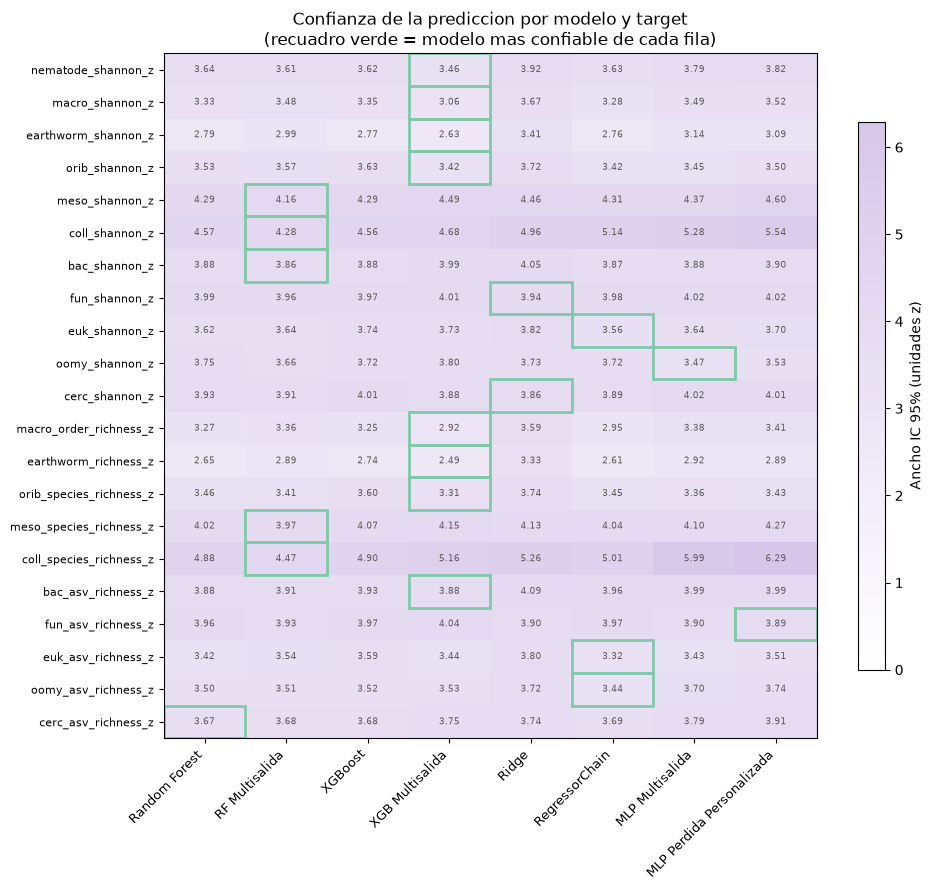

In [23]:
PALETTE_CMAP_CONF = LinearSegmentedColormap.from_list(
    'sob4es_confianza', ['#FFFFFF', PALETTE['purple_light']]
)

fig, ax = plt.subplots(figsize=(10, 9))
data_ic = df_ic_ancho.values
im = ax.imshow(data_ic, cmap=PALETTE_CMAP_CONF, vmin=0, aspect='auto')

ax.set_xticks(range(len(MODELOS)))
ax.set_xticklabels(MODELOS, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(TARGETS)))
ax.set_yticklabels(TARGETS, fontsize=8)

for i in range(len(TARGETS)):
    for j in range(len(MODELOS)):
        ax.text(j, i, f'{data_ic[i, j]:.2f}', ha='center', va='center', fontsize=6.5,
                color=PALETTE['gray_dark'])

for i, target in enumerate(TARGETS):
    j = MODELOS.index(modelo_mas_confiable_por_target[target])
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                edgecolor=PALETTE['green'], linewidth=2.0))

fig.colorbar(im, ax=ax, label='Ancho IC 95% (unidades z)', shrink=0.8)
ax.set_title('Confianza de la prediccion por modelo y target\n(recuadro verde = modelo mas confiable de cada fila)', fontsize=12)
plt.tight_layout()
plt.show()


### 6.3 Calculo empirico a partir del ensamble (solo con recalculo en vivo)

Cuando se dispone de los modelos reales (`PREDICCIONES_MIEMBROS` no vacio), se puede calcular un IC **por observacion** en vez de una unica aproximacion global por target: para cada fila de `eval.csv` se toma la media y la desviacion estandar entre los miembros del ensamble, y se construye el IC 95% con el cuantil de la t de Student (`df = n_miembros - 1`). Esto es mas informativo porque revela si la incertidumbre es homogenea o si hay observaciones concretas mucho mas dificiles de predecir que otras.

Para los modelos con ensamble real de produccion (Random Forest, XGBoost, sus versiones multisalida, RegressorChain y ambos MLP) esto usa directamente sus miembros ya entrenados. Para **Ridge**, que no tiene ensamble propio, se usa en su lugar el pseudo-ensamble por bootstrap de la Seccion 2 (si `train.csv` estaba disponible); su IC empirico debe interpretarse con mas cautela, ya que refleja la variabilidad del reentrenamiento sobre remuestreos, no la de un ensamble de produccion real.


Comparacion: IC empirico (dispersion real del ensamble) vs. IC aproximado (a partir de R2)
------------------------------------------------------------------------------------------
                   modelo                  target  ancho_ic_medio_empirico  ancho_ic_aproximado_r2
            Random Forest      nematode_shannon_z                    0.201                   3.644
            Random Forest         macro_shannon_z                    0.235                   3.329
            Random Forest     earthworm_shannon_z                    0.232                   2.791
            Random Forest          orib_shannon_z                    0.209                   3.532
            Random Forest          meso_shannon_z                    0.191                   4.293
            Random Forest          coll_shannon_z                    0.250                   4.566
            Random Forest           bac_shannon_z                    0.192                   3.881
            Random Forest 

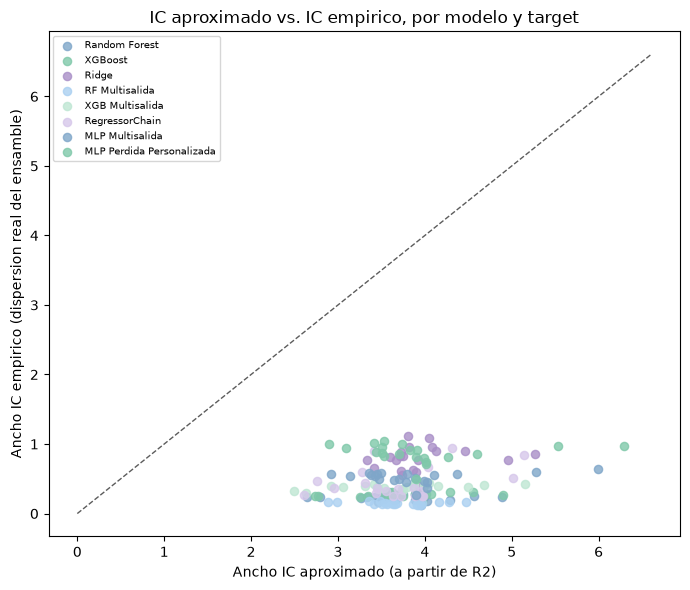

In [24]:
if PREDICCIONES_MIEMBROS:
    resumen_empirico = []
    for modelo, targets_dict in PREDICCIONES_MIEMBROS.items():
        for target, miembros in targets_dict.items():
            n_miembros = miembros.shape[0]
            media_obs  = miembros.mean(axis=0)
            std_obs    = miembros.std(axis=0, ddof=1)
            t_mult     = stats.t.ppf(0.975, df=n_miembros - 1)
            ancho_ic_obs = 2 * t_mult * std_obs

            resumen_empirico.append({
                'modelo': modelo,
                'target': target,
                'ancho_ic_medio_empirico': ancho_ic_obs.mean(),
                'ancho_ic_aproximado_r2':  df_ic_ancho.loc[target, modelo],
            })

    df_empirico = pd.DataFrame(resumen_empirico)
    print('Comparacion: IC empirico (dispersion real del ensamble) vs. IC aproximado (a partir de R2)')
    print('-' * 90)
    print(df_empirico.round(3).to_string(index=False))

    print('\nInterpretacion: si el IC empirico es mucho mas estrecho que el aproximado, el')
    print('ensamble concuerda entre si pero probablemente comparte el mismo sesgo (subestima')
    print('la incertidumbre real). Si es mucho mas ancho, indica alta variabilidad entre')
    print('miembros del ensamble para ese target: senal de un modelo poco estable.')

    # Grafico: dispersion IC empirico vs aproximado, por modelo
    fig, ax = plt.subplots(figsize=(7, 6))
    for modelo, color in zip(df_empirico['modelo'].unique(), palette_cycle(df_empirico['modelo'].nunique())):
        sub = df_empirico[df_empirico['modelo'] == modelo]
        ax.scatter(sub['ancho_ic_aproximado_r2'], sub['ancho_ic_medio_empirico'],
                   label=modelo, color=color, s=35, alpha=0.8)
    lim = [0, max(df_empirico['ancho_ic_aproximado_r2'].max(), df_empirico['ancho_ic_medio_empirico'].max()) * 1.05]
    ax.plot(lim, lim, '--', color=PALETTE['gray_dark'], linewidth=1)
    ax.set_xlabel('Ancho IC aproximado (a partir de R2)')
    ax.set_ylabel('Ancho IC empirico (dispersion real del ensamble)')
    ax.set_title('IC aproximado vs. IC empirico, por modelo y target', fontsize=12)
    ax.legend(fontsize=7, loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('PREDICCIONES_MIEMBROS esta vacio: no hay modelos/datos reales cargados en este entorno.')
    print('Se mantiene unicamente la aproximacion basada en R2 (secciones 6.1 y 6.2).')
    print('Para obtener el calculo empirico, ejecuta este notebook en un entorno con')
    print('input/eval.csv y las carpetas output/models/... generadas por cada notebook.')


## 7.- Conclusiones

- El **ranking global** (seccion 3.1) resume que modelo generaliza mejor en promedio, pero ningun modelo gana en todos los targets: conviene mirar tambien la seccion 4 antes de descartar un enfoque por completo.
- Un target aparece como "dificil para todos" cuando su R2 maximo entre los 8 modelos es bajo o negativo (p. ej. `coll_species_richness_z`, `meso_shannon_z`); en esos casos el problema es probablemente de señal disponible en los datos, no de eleccion de modelo.
- Un modelo que aparece muchas veces como "menos relevante" en targets donde otros modelos si consiguen R2 razonable es un buen candidato a revisar (hiperparametros, arquitectura o cantidad de datos de entrenamiento).
- Esta comparativa debe interpretarse junto con la variabilidad del ensamble (ver seccion de validacion cruzada de cada notebook individual), ya que un unico valor de R2 sobre 65 filas de `eval.csv` tiene incertidumbre no despreciable.
- Para la incertidumbre de una prediccion puntual concreta, la seccion 6 (confianza) es mas informativa que el R2 solo: dos modelos con R2 parecido pueden tener anchos de intervalo de confianza distintos.
